In [1]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np


In [2]:
from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

sp_D = sp.symbols('D', positive=True, integer=True)
sp_D = 2

sp_L = sp.symbols('L', positive=True, real=True)
sp_L = 5*sp.pi
sp_N = sp.symbols('N', positive=True, integer=True)
sp_N = 256

sp_kmin = (sp.S(2)*sp.pi/sp_L)
sp_kmax = (sp.pi*sp_N/sp_L)

b = sp_kmin

sp_E = sp.exp(-k/b)

norm = sp.S(1)/(sp.S(2)*sp.pi)**sp_D

sig = norm * sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * k * sp_E), (k, 0, sp.oo))
Ef = sp_E / sig

s = sp.symbols('sigma', real=True, positive=True)
xi = sp.symbols('xi', real=True, positive=True)

Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2)

S_D = sp.S(2)*sp.pi**(sp_D/2)/sp.gamma(sp_D/2)

Vs_num = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * Ef * sp.Abs(Hk)**2, (k, 0, sp.oo))

Vs_denom = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * sp.Abs(Hk)**2, (k, 0, sp.oo))
Vs = Vs_num / Vs_denom

display(Vs.simplify())


         ⎛                                25       ⎛                     ⎛    
         ⎜                              ─────      ⎜                     ⎜    
         ⎜                                  2      ⎜                     ⎜    
     0.5 ⎜     ⎛     4        2      ⎞  16⋅σ       ⎜      5        3     ⎜    
-25⋅π   ⋅⎜25⋅π⋅⎝192⋅σ  + 400⋅σ  + 125⎠⋅ℯ      + √π⋅⎜1792⋅σ  + 800⋅σ  - 5⋅⎜4⋅σ 
         ⎝                                         ⎝                     ⎝    
──────────────────────────────────────────────────────────────────────────────
                                                                  5           
                                                            8192⋅σ            

          25          ⎞                        ⎞⎞ 
        ─────         ⎟                        ⎟⎟ 
            2         ⎟                        ⎟⎟ 
        16⋅σ     ⎛ 5 ⎞⎟ ⎛     4        2      ⎞⎟⎟ 
+ 5⋅√π⋅ℯ     ⋅erf⎜───⎟⎟⋅⎝192⋅σ  + 400⋅σ  + 125⎠⎟⎟ 
                 ⎝4⋅σ⎠⎠          

In [3]:
display(sp.limit(Vs.simplify(), s, sp.oo))
display(sp.limit(Vs.simplify(), s, 0))

display(sp.limit(Vs.simplify(), s, np.sqrt(2.*sp_D + 6.)/(2.*sp_kmin)).evalf())
display(sp.limit(Vs.simplify(), s, np.sqrt(2.*sp_D + 6.)/(2.*19.)).evalf())

25⋅π
────
 4  

0

7.18926738509408

8.40088473038244e+86

0.4 3.5355339059327378 6.42289933674251
0.4200925120526379 3.3664336349701305 6.09004648306152
0.44119429670673926 3.2054212235502204 5.76068547882939
0.4633560510170774 3.0521098392237747 5.43565339906193
0.48663101861638564 2.9061311512654084 5.11578691626734
0.5110751176332285 2.7671344457587175 4.80191467977288
0.5367470750353509 2.63478578300581 4.4948492901288
0.5637085677212657 2.5087671952369095 4.19537898003004
0.5920243706990527 2.388775922692532 3.90425913210518
0.6217625127083678 2.274523686242917 3.6222037812928
0.652994439659546 2.1657359947971817 3.34987726448322
0.6857951862824583 2.0621514858382564 3.08788619174585
0.7202435563975116 1.9635212974992209 2.83677192087796
0.756422312241891 1.8696084706724696 2.59700371936564
0.7944183733059019 1.780187379715263 2.3689727943912
0.8343230251571165 1.6950431903839354 2.15298736170345
0.8762321387540232 1.613971343694453 1.94926890764308
0.9202464007760828 1.5367770644692866 1.7579497753525
0.966471555523558 1.463274893389889

Text(0.5, 0, 'Wavenumber, $k_{\\sigma}$')

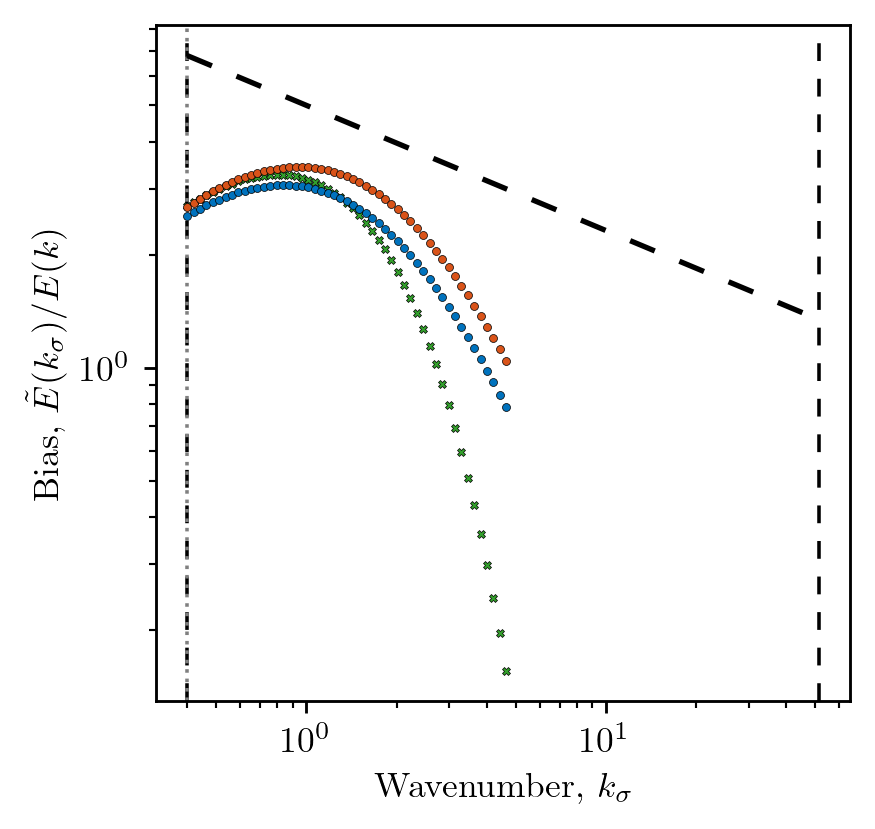

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lam_E = sp.lambdify(k, Ef, modules=['mpmath'])
lam_V = sp.lambdify(s, Vs, modules=['mpmath'])

_kk = np.exp(np.linspace(np.log(float(sp_kmin.evalf())), np.log(float(sp_kmax.evalf())), 100))

for _k in _kk:

    if _k > 4.87:
        continue

    _s = np.sqrt(2.)/_k
    num = lam_V(float(_s))
    denom = lam_E(float(_k))
    print(_k, _s, num)
    to_omni = float(S_D.evalf() * _k**(sp_D-1))
    ax.scatter(_k, np.sqrt(_k * to_omni * num), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

    _s = np.sqrt(2.*sp_D + 6.)/(2.*_k)
    num = lam_V(float(_s))
    ax.scatter(_k, np.sqrt(_k * to_omni * num), marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    ax.scatter(_k, np.sqrt(_k * to_omni * denom), marker='X', s=5., color=c[2], zorder=0, linewidth=0.2, edgecolor='black')

ax.plot(_kk, 5*_kk**(-1./3.), color='black', linestyle=(0,(5,5)), linewidth=1.5)

ax.loglog()

ax.axvline(float(sp_kmin.evalf()), color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)
ax.axvline(float(sp_kmax.evalf()), color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)

ax.axvline(b.evalf(), color='gray', linewidth=1., linestyle=':', zorder=0)

ax.set_ylabel('Bias, $\\tilde{E}(k_{\sigma})/E(k)$')
ax.set_xlabel('Wavenumber, $k_{\sigma}$')